In [5]:
pip install pandas numpy seaborn matplotlib

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 999.2 kB/s eta 0:00:10
   ---- ----------------------------------- 1.0/9.9 MB 1.6 MB/s eta 0:00:06
   ------ --------------------------------- 1.6/9.9 MB 1.7 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.9 MB 1.9 MB/s eta 0:00:05
   ----------- ---------------------------- 2.9/9.9 MB 2.3 MB/s eta 0:00:04
   ------------ --------------------------- 3.1/9.9 MB 2.3 MB/s eta 0:00:03
   --------------- ------------------------ 3.9/9.9 MB 2.2 MB/s eta 0:00:03
   --------------------- ------------------ 5.2/9.9 MB 2.7 MB/s eta 0:00:02
   -------------------------- ------------- 6.6/9.9 MB 3.1 MB/s eta 0:00:02
   -------------------------------- ------- 8.1/9.9 MB 3.5 MB/s eta 0:00:01
   ----------------------------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Load dataset

df = pd.read_csv("auto_imports.csv", header=None)

# Display first 5 rows

df.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [8]:
# Assign column names

df.columns = [
    'symboling','normalized_losses','make','fuel_type',
    'aspiration','num_of_doors','body_style',
    'drive_wheels','engine_location','wheel_base',
    'length','width','height','curb_weight',
    'engine_type','num_of_cylinders','engine_size',
    'fuel_system','bore','stroke',
    'compression_ratio','horsepower','peak_rpm',
    'city_mpg','highway_mpg','price'
]

df.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [9]:
df.shape

(201, 26)

Number of rows and columns

In [44]:
df.info

<bound method DataFrame.info of      symboling  normalized_losses         make fuel_type aspiration  \
0            3              115.0  alfa-romero       gas        std   
1            3              115.0  alfa-romero       gas        std   
2            1              115.0  alfa-romero       gas        std   
3            2              164.0         audi       gas        std   
4            2              164.0         audi       gas        std   
..         ...                ...          ...       ...        ...   
196         -1               95.0        volvo       gas        std   
197         -1               95.0        volvo       gas      turbo   
198         -1               95.0        volvo       gas        std   
199         -1               95.0        volvo    diesel      turbo   
200         -1               95.0        volvo       gas      turbo   

    num_of_doors   body_style drive_wheels engine_location  wheel_base  ...  \
0            two  convertible       

In [11]:
# Replace ? with NaN

df.replace('?', np.nan, inplace=True)

# Check missing values

df.isnull().sum()

symboling             0
normalized_losses    37
make                  0
fuel_type             0
aspiration            0
num_of_doors          2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_of_cylinders      0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 0
dtype: int64

In [12]:
# Check duplicates

df.duplicated().sum()

np.int64(0)

In [13]:
# Convert columns to numeric datatype

cols = [
    'normalized_losses',
    'bore',
    'stroke',
    'horsepower',
    'peak_rpm',
    'price'
]

for col in cols:
    df[col] = pd.to_numeric(df[col])

In [17]:
# Fill numerical missing values
num_cols = df.select_dtypes(include="number").columns

# Calculate medians for those columns
medians = df[num_cols].median()

# Fill missing values directly in the dataframe
df[num_cols] = df[num_cols].fillna(medians)

In [43]:
# Fill categorical missing values
cat_cols = df.select_dtypes(include=["object", "string"]).columns

# Calculate mode and fill missing values explicitly
for col in cat_cols:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])

In [22]:
# Summary statistics

df.describe()

,symboling,normalized_losses,wheel_base,length,width,height,curb_weight,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,120.711443,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,3.330299,3.257562,10.164279,103.313433,5118.407960,25.179104,30.686567,13207.129353
std,1.254802,32.111623,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,0.268088,0.316082,4.004965,37.374942,478.183493,6.423220,6.815150,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,101.000000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,137.000000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000


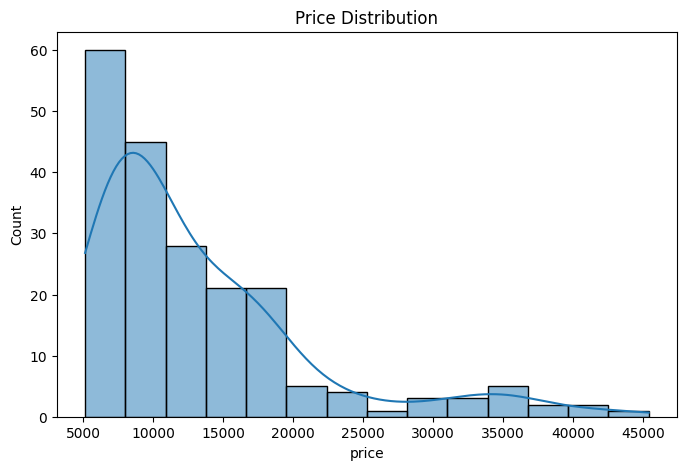

In [23]:
# Distribution of car prices

plt.figure(figsize=(8,5))

sns.histplot(df['price'], kde=True)

plt.title("Price Distribution")

plt.show()

Price distribution is right skewed.

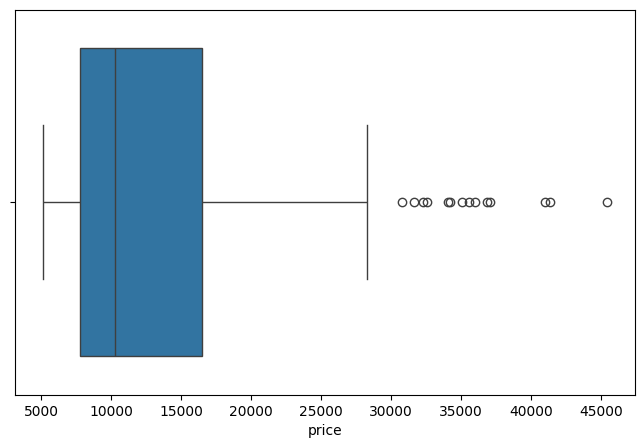

In [24]:
# Detect outliers

plt.figure(figsize=(8,5))

sns.boxplot(x=df['price'])

plt.show()

Some high priced vehicles are present.

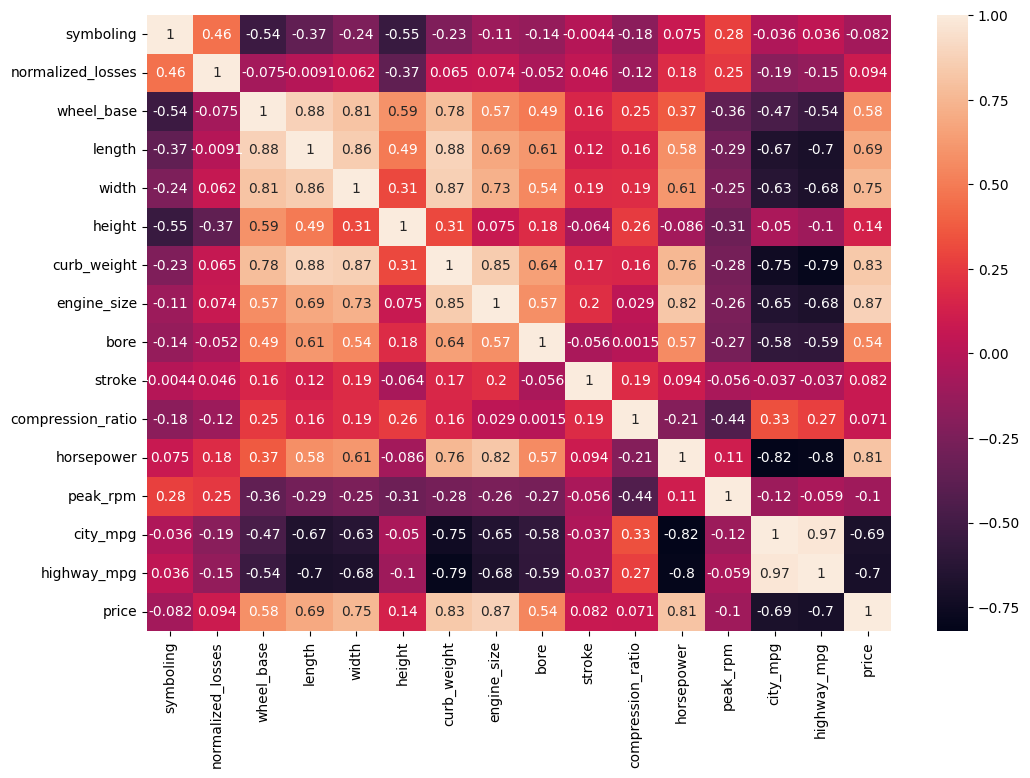

In [25]:
# Correlation between numerical columns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.show()

Engine size and horsepower show strong correlation with price.

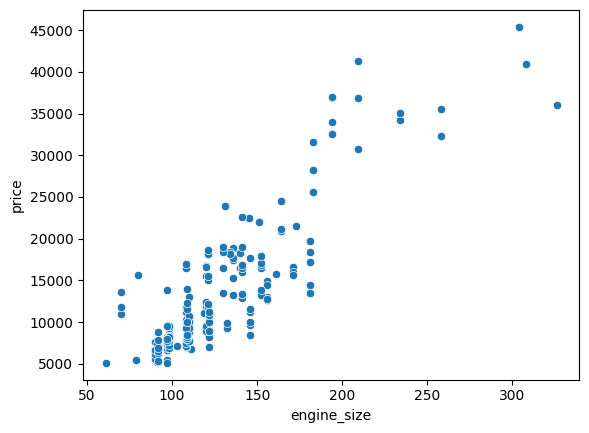

In [26]:
# Relationship between engine size and price

sns.scatterplot(
    x='engine_size',
    y='price',
    data=df
)

plt.show()

Price increases as engine size increases.

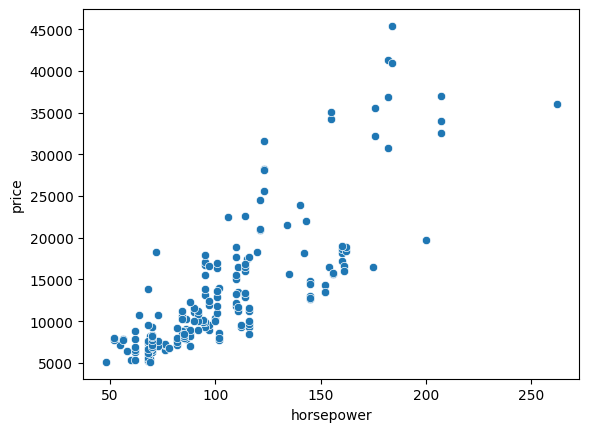

In [27]:
# Relationship between horsepower and price

sns.scatterplot(
    x='horsepower',
    y='price',
    data=df
)

plt.show()

Cars with higher horsepower have higher prices.

In [28]:
# Convert categorical variables

df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [29]:
# Independent variables

X = df_encoded.drop('price', axis=1)

# Dependent variable

y = df_encoded['price']

In [31]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 2.0 MB/s eta 0:00:04
   ----- ---------------------------------- 1.0/8.3 MB 1.8 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.3 MB 1.8 MB/s eta 0:00:04
   ------- -------------------------------- 1.6/8.3 MB 1.6 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.3 MB 1.6 MB/s eta 0:00:05
   -------- ------------------------------- 1.8/8.3 MB 1.2 MB/s eta 0:00:06
   -------- ------------------------------- 1.8/8.3 MB 1.2 MB/s eta 0:00:06
   ---------- ----------------------------- 2.1/8.3 MB 1.1 MB/s eta 0:00:06
   ---------- ----------------------------- 2.1/8.3 MB 1.1 MB/s eta 0:00:06
   ----------- ---------------------------- 2.4/8.3 MB 968.5 kB/s eta 0:00:07
   ----------- ---------------------------- 2.4/8.3 MB 968.5 kB/s eta 0:00:07
   ------------ ------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
# Import train_test_split function

from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% of data is used for training
# 20% of data is used for testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train-Test Split is performed to evaluate the model's performance on unseen data.

X_train:
Contains the feature data used for training the model.

X_test:
Contains the feature data used for testing the model.

y_train:
Contains the actual car prices used during model training.

y_test:
Contains the actual car prices used for model evaluation.

80% of the dataset is allocated for training and 20% for testing.

The random_state parameter is set to 42 to ensure reproducibility of results.

In [33]:
# Check the shape of training and testing datasets

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (160, 64)
X_test Shape: (41, 64)
y_train Shape: (160,)
y_test Shape: (41,)


The dataset was successfully divided into training and testing sets.

Training data is used to train the machine learning models, while testing data is used to evaluate model performance on unseen records.

In [34]:
# Import Linear Regression model

from sklearn.linear_model import LinearRegression

# Create Linear Regression object

lr = LinearRegression()

# Train the model using training data

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](64,)","[-129.66, -4.56, 195.31,...,1939.62,1128.34,2752.89]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](64,)","['symboling','normalized_losses','wheel_base',...,'fuel_system_mpfi', 'fuel_system_spdi','fuel_system_spfi']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1681
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,64
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,59


Linear Regression is used as a baseline model to understand the relationship between independent variables and car price.

In [35]:
# Predict car prices using test data

pred_lr = lr.predict(X_test)

The trained model predicts car prices for the test dataset.

In [36]:
# Import evaluation metric

from sklearn.metrics import r2_score

# Calculate R² Score

lr_r2 = r2_score(y_test, pred_lr)

print("Linear Regression R2 Score:", lr_r2)

Linear Regression R2 Score: 0.9110414074340099


R² Score measures how well the model explains the variation in car prices.
A value closer to 1 indicates better model performance.

In [37]:
# Import Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model

rf = RandomForestRegressor(random_state=42)

# Train the model

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

Random Forest combines multiple decision trees and generally provides better prediction accuracy than a single model.

In [38]:
# Predict prices using Random Forest

pred_rf = rf.predict(X_test)

The trained Random Forest model predicts car prices for the test data.

In [39]:
# Calculate Random Forest R² Score

rf_r2 = r2_score(y_test, pred_rf)

print("Random Forest R2 Score:", rf_r2)

Random Forest R2 Score: 0.927119217906593


The Random Forest model performance is evaluated using R² Score.
Higher R² indicates better predictive capability.

In [40]:
# Compare Linear Regression and Random Forest performance

print("Linear Regression :", lr_r2)
print("Random Forest :", rf_r2)

Linear Regression : 0.9110414074340099
Random Forest : 0.927119217906593


The model with the higher R² Score is considered the better-performing model for car price prediction.

In [41]:
# Identify important features affecting car price

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
6,curb_weight,0.432456
7,engine_size,0.307185
14,highway_mpg,0.057346
11,horsepower,0.053517
13,city_mpg,0.039853
4,width,0.029675
2,wheel_base,0.011873
16,make_bmw,0.009772
12,peak_rpm,0.007538
1,normalized_losses,0.007024


Feature Importance helps identify which variables have the greatest influence on car prices.

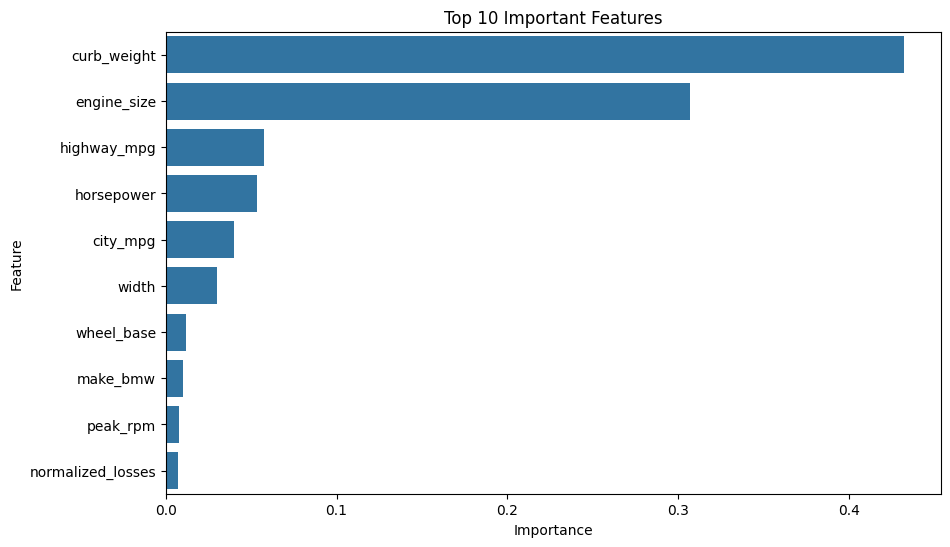

In [42]:
# Display top 10 important features

top10 = importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top10
)

plt.title("Top 10 Important Features")

plt.show()

The chart visually represents the most influential factors affecting car prices.

Conclusion:

1. Data cleaning and preprocessing were performed successfully.

2. Exploratory Data Analysis revealed that Engine Size and Horsepower have a strong relationship with Price.

3. Multiple machine learning models were developed and evaluated.

4. Random Forest achieved the best performance among the tested models.

5. Engine Size, Horsepower, and Curb Weight were identified as the most important factors influencing car prices.

6. Therefore, Random Forest is recommended for predicting car prices in production.